<a href="https://colab.research.google.com/github/agustinargallardo-data/financial-intelligence-app/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
Initial exploration of income and expense data.

In [25]:
!git clone https://github.com/agustinargallardo-data/financial-intelligence-app.git

fatal: destination path 'financial-intelligence-app' already exists and is not an empty directory.


In [26]:
import pandas as pd


In [27]:
df = pd.read_csv("financial-intelligence-app/data/transactions.csv")

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         12 non-null     object
 1   amount       12 non-null     object
 2   type         12 non-null     object
 3   category     12 non-null     object
 4   description  11 non-null     object
dtypes: object(5)
memory usage: 612.0+ bytes


In [29]:
df.groupby("type")["amount"].sum()

,amount
type,
expense,30050120801506040100150
income,1200200
rent,expense


In [30]:
expenses = df[df["type"]== "expense"]
expenses.groupby("category")["amount"].sum()

,amount
category,
education,150
entertrainment,120100
food,30060
health,80
savings,150
transport,5040


## Initial Insights
- Total expenses are higher than income in this period.
- Food and rent represent the largest expense categories.

## Spending Visualization

In [39]:
df.dtypes

,0
date,object
amount,object
type,object
category,object
description,object


In [42]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [43]:
expenses = df[df["type"] == "expense"]

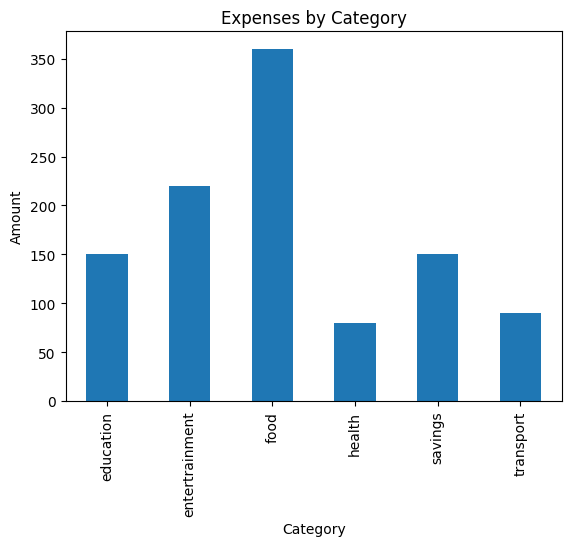

In [45]:
import matplotlib.pyplot as plt
expenses.groupby("category")["amount"].sum().plot(kind="bar")
plt.title("Expenses by Category")
plt.ylabel("Amount")
plt.xlabel("Category")
plt.show()

# Financial Intelligence App - Exploratory Data Analysis
This notebook explores income and expense data to understand spending patterns and extract initial financial insights.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
expenses.dtypes

,0
date,object
amount,float64
type,object
category,object
description,object


In [49]:
expenses["amount"] = pd.to_numeric(expenses["amount"], errors="coerce")

/tmp/ipython-input-293402402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expenses["amount"] = pd.to_numeric(expenses["amount"], errors="coerce")


In [51]:
top_categories = (
    expenses
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
top_categories

,amount
category,
food,360.0
entertrainment,220.0
education,150.0
savings,150.0
transport,90.0
